# Experiment 1 — H5 Recovery, Inference, and Metrics

This notebook continues **Experiment 1 without retraining**. It loads the saved final-epoch H5 model, verifies its inference contract, recovers the validation class mapping, regenerates evaluation metrics and confusion matrices, and tests individual images.

> Research and educational use only. This model is not validated for diagnosis or clinical decision-making.

## Prepare the validation dataset

This optional Colab-oriented section downloads LC25000 and creates the same five-class directory layout used by Experiment 1. Skip these cells when `DATASET_DIR` already points to an existing `LungColon` directory.

In [1]:
import os
import shutil
from pathlib import Path

import kagglehub

DATASET_DIR = Path(os.getenv("DATASET_DIR", "./LungColon")).resolve()
dataset_cache = Path(
    kagglehub.dataset_download(
        "andrewmvd/lung-and-colon-cancer-histopathological-images"
    )
)

print(f"Kaggle cache: {dataset_cache}")
print(f"Validation dataset destination: {DATASET_DIR}")

100%|██████████| 1.76G/1.76G [00:22<00:00, 83.9MB/s]

Extracting files...


Kaggle cache: /root/.cache/kagglehub/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images/versions/1
Validation dataset destination: /content/LungColon


In [2]:
DATASET_DIR.mkdir(parents=True, exist_ok=True)

source_directories = (
    dataset_cache / "lung_colon_image_set" / "colon_image_sets",
    dataset_cache / "lung_colon_image_set" / "lung_image_sets",
)

for source_directory in source_directories:
    for class_directory in source_directory.iterdir():
        if class_directory.is_dir():
            shutil.copytree(
                class_directory,
                DATASET_DIR / class_directory.name,
                dirs_exist_ok=True,
            )

class_counts = {
    class_directory.name: len(list(class_directory.glob("*.jpeg")))
    for class_directory in sorted(DATASET_DIR.iterdir())
    if class_directory.is_dir()
}
print("Recovered class counts:", class_counts)
print("Total images:", sum(class_counts.values()))

Recovered class counts: {'colon_aca': 5000, 'colon_n': 5000, 'lung_aca': 5000, 'lung_n': 5000, 'lung_scc': 5000}
Total images: 25000


## 1. Environment and configurable paths

Run the notebook from `research/experiment1`, or set `EXPERIMENT_DIR`, `MODEL_PATH`, and `DATASET_DIR` environment variables. No machine-specific absolute paths are required.

In [ ]:
import hashlib
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from tensorflow import keras
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

EXPERIMENT_DIR = Path(os.getenv("EXPERIMENT_DIR", ".")).resolve()
MODEL_PATH = Path(os.getenv("MODEL_PATH", EXPERIMENT_DIR / "model.h5")).resolve()
DATASET_DIR = Path(os.getenv("DATASET_DIR", EXPERIMENT_DIR / "LungColon")).resolve()
OUTPUT_DIR = Path(os.getenv("OUTPUT_DIR", EXPERIMENT_DIR / "outputs")).resolve()

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 128
VALIDATION_SPLIT = 0.2
SEED = 42
EXPERIMENT_ID = "exp-1"
DATASET_ID = "andrewmvd/lung-and-colon-cancer-histopathological-images"
MODEL_ARCHITECTURE = "EfficientNetB7"
EXPECTED_CLASS_INDICES = {
    "colon_aca": 0,
    "colon_n": 1,
    "lung_aca": 2,
    "lung_n": 3,
    "lung_scc": 4,
}

print(f"TensorFlow: {tf.__version__}")
print(f"Model:      {MODEL_PATH}")
print(f"Dataset:    {DATASET_DIR}")
print(f"Outputs:    {OUTPUT_DIR}")

## 2. Verify and recover the saved H5 model

`compile=False` avoids restoring training-only optimizer state. The recovered model is used only for inference and metrics.

In [4]:
if not MODEL_PATH.is_file():
    raise FileNotFoundError(
        f"Model not found at {MODEL_PATH}. Set MODEL_PATH or run from the experiment directory."
    )

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

model_sha256 = sha256_file(MODEL_PATH)
model = keras.models.load_model(MODEL_PATH, compile=False)

assert tuple(model.input_shape[1:]) == (*IMAGE_SIZE, 3), model.input_shape
assert model.output_shape[-1] == len(EXPECTED_CLASS_INDICES), model.output_shape

print(f"Loaded:       {model.name}")
print(f"Input shape:  {model.input_shape}")
print(f"Output shape: {model.output_shape}")
print(f"SHA-256:      {model_sha256}")

Loaded:       functional
Input shape:  (None, 224, 224, 3)
Output shape: (None, 5)
SHA-256:      b746aef5199588d1d68c2c42717543171cba30ba377dca6aa740fdc09a81e97f


## 3. Rebuild the original validation stream

This deliberately matches the training notebook: RGB, 224×224, EfficientNet preprocessing, the validation subset with seed 42, and no shuffling. If the dataset is unavailable, model recovery and single-image inference can still run.

In [5]:
validation = None
ordered_labels = [
    label for label, index in sorted(EXPECTED_CLASS_INDICES.items(), key=lambda item: item[1])
]

if not DATASET_DIR.is_dir():
    print("Dataset directory not found; full metrics will be skipped.")
    print("Set DATASET_DIR to the LungColon directory and rerun from this cell.")
else:
    validation_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        validation_split=VALIDATION_SPLIT,
    )
    validation = validation_datagen.flow_from_directory(
        DATASET_DIR,
        class_mode="categorical",
        target_size=IMAGE_SIZE,
        color_mode="rgb",
        batch_size=BATCH_SIZE,
        shuffle=False,
        subset="validation",
        seed=SEED,
    )
    print("Recovered class_indices:", validation.class_indices)
    if validation.class_indices != EXPECTED_CLASS_INDICES:
        raise ValueError(
            "Dataset class order differs from the saved Experiment 1 contract: "
            f"{validation.class_indices}"
        )

Found 5000 images belonging to 5 classes.
Recovered class_indices: {'colon_aca': 0, 'colon_n': 1, 'lung_aca': 2, 'lung_n': 3, 'lung_scc': 4}


## 4. Regenerate the classification report

The generator is reset before prediction so labels and prediction rows remain aligned.

In [6]:
report_dict = None
y_true = None
y_pred = None
probabilities = None

if validation is None:
    print("Skipped: validation dataset is unavailable.")
else:
    validation.reset()
    probabilities = model.predict(validation, verbose=1)
    y_true = validation.classes
    y_pred = np.argmax(probabilities, axis=1)

    if probabilities.shape != (len(y_true), len(ordered_labels)):
        raise ValueError(f"Unexpected prediction shape: {probabilities.shape}")
    if not np.isfinite(probabilities).all():
        raise ValueError("Predictions contain NaN or infinite values.")

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=ordered_labels,
        output_dict=True,
        zero_division=0,
    )
    display(pd.DataFrame(report_dict).transpose())

40/40 ━━━━━━━━━━━━━━━━━━━━ 2967s 74s/step


,precision,recall,f1-score,support
colon_aca,0.995020,0.999,0.997006,1000.000
colon_n,1.000000,0.995,0.997494,1000.000
lung_aca,0.988922,0.982,0.985449,1000.000
lung_n,0.990099,1.000,0.995025,1000.000
lung_scc,0.990982,0.989,0.989990,1000.000
accuracy,0.993000,0.993,0.993000,0.993
macro avg,0.993005,0.993,0.992993,5000.000
weighted avg,0.993005,0.993,0.992993,5000.000


## 5. Finish the missing confusion matrices

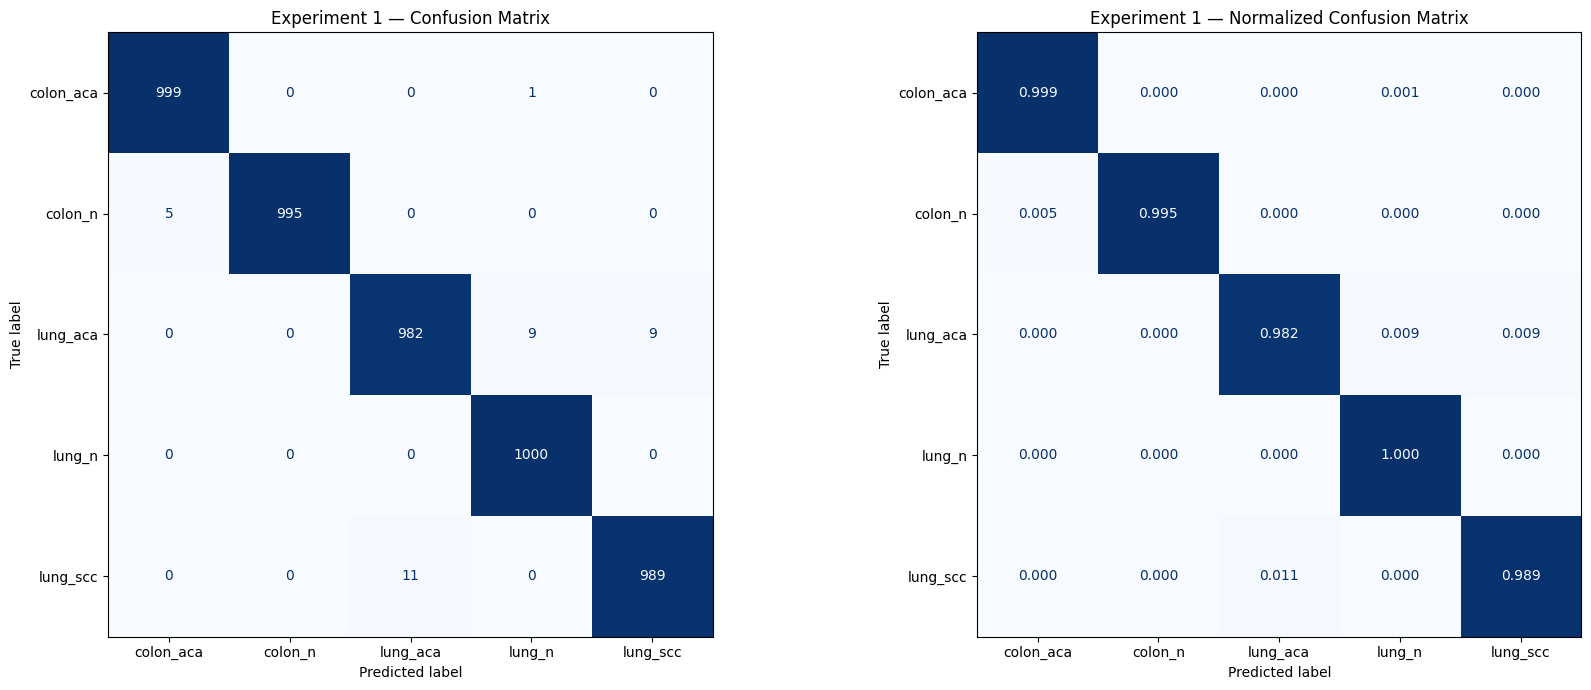

In [7]:
raw_confusion_matrix = None
normalized_confusion_matrix = None

if y_true is None or y_pred is None:
    print("Skipped: predictions have not been generated.")
else:
    raw_confusion_matrix = confusion_matrix(y_true, y_pred)
    normalized_confusion_matrix = confusion_matrix(y_true, y_pred, normalize="true")

    figure, axes = plt.subplots(1, 2, figsize=(18, 7))
    ConfusionMatrixDisplay(raw_confusion_matrix, display_labels=ordered_labels).plot(
        ax=axes[0], cmap="Blues", colorbar=False, values_format="d"
    )
    axes[0].set_title("Experiment 1 — Confusion Matrix")

    ConfusionMatrixDisplay(normalized_confusion_matrix, display_labels=ordered_labels).plot(
        ax=axes[1], cmap="Blues", colorbar=False, values_format=".3f"
    )
    axes[1].set_title("Experiment 1 — Normalized Confusion Matrix")
    figure.tight_layout()
    plt.show()

## 6. Test a single image exactly as the frontend should

Set `SAMPLE_IMAGE` to any supported image path. The function returns all five scores, not only the winning class. The maximum softmax score is model confidence, not a calibrated clinical probability.

In [ ]:
def predict_image(image_path: Path) -> pd.DataFrame:
    image_path = Path(image_path)
    if not image_path.is_file():
        raise FileNotFoundError(image_path)

    loaded_image = keras.utils.load_img(
        image_path, target_size=IMAGE_SIZE, color_mode="rgb"
    )
    image_array = keras.utils.img_to_array(loaded_image)
    image_batch = np.expand_dims(image_array, axis=0)
    image_batch = preprocess_input(image_batch)

    scores = model.predict(image_batch, verbose=0)[0]
    if scores.shape != (len(ordered_labels),) or not np.isfinite(scores).all():
        raise ValueError(f"Invalid prediction output: shape={scores.shape}")

    result = pd.DataFrame({"class_name": ordered_labels, "score": scores})
    return result.sort_values("score", ascending=False, ignore_index=True)


sample_image_value = os.getenv("SAMPLE_IMAGE")
expected_class = None

if sample_image_value:
    reference_image_path = Path(sample_image_value)
elif validation is not None and validation.filepaths:
    reference_image_path = Path(validation.filepaths[0])
    expected_class = ordered_labels[int(validation.classes[0])]
else:
    reference_image_path = None

reference_prediction = None
if reference_image_path is None:
    print("No reference image is available. Set SAMPLE_IMAGE and rerun this cell.")
else:
    reference_scores = predict_image(reference_image_path)
    predicted_class = str(reference_scores.iloc[0]["class_name"])
    try:
        dataset_relative_path = reference_image_path.resolve().relative_to(
            DATASET_DIR.resolve()
        ).as_posix()
    except ValueError:
        dataset_relative_path = None
    reference_image_sha256 = sha256_file(reference_image_path)
    reference_prediction = {
        "image_filename": reference_image_path.name,
        "image_sha256": reference_image_sha256,
        "dataset_id": DATASET_ID,
        "dataset_relative_path": dataset_relative_path,
        "expected_class": expected_class,
        "predicted_class": predicted_class,
        "scores": {
            str(row.class_name): float(row.score)
            for row in reference_scores.itertuples(index=False)
        },
    }
    print(f"Reference image: {reference_image_path.name}")
    print(f"Expected class: {expected_class or 'not supplied'}")
    print(f"Predicted class: {predicted_class}")
    display(reference_scores)

## 7. Export recovered metadata and metrics

These small files can be reviewed and versioned separately from the 263 MB model.

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

manifest = {
    "schema_version": 1,
    "experiment_id": EXPERIMENT_ID,
    "architecture": MODEL_ARCHITECTURE,
    "dataset": {
        "id": DATASET_ID,
        "split_method": "ImageDataGenerator validation_split at image level",
    },
    "model_file": MODEL_PATH.name,
    "model_sha256": model_sha256,
    "framework": "tensorflow.keras",
    "tensorflow_version_used_for_recovery": tf.__version__,
    "keras_version_used_for_recovery": keras.__version__,
    "input": {
        "height": IMAGE_SIZE[0],
        "width": IMAGE_SIZE[1],
        "channels": 3,
        "color_mode": "rgb",
        "dtype": "float32",
        "resize_interpolation": "nearest",
        "preprocessing": "tensorflow.keras.applications.efficientnet.preprocess_input",
    },
    "output": {
        "type": "softmax_probabilities",
        "class_indices": EXPECTED_CLASS_INDICES,
    },
    "evaluation": {
        "validation_split": VALIDATION_SPLIT,
        "seed": SEED,
        "sample_count": None if y_true is None else int(len(y_true)),
        "accuracy": None if report_dict is None else float(report_dict["accuracy"]),
        "reference_prediction_file": (
            None if reference_prediction is None else "reference_prediction.json"
        ),
        "reference_image_file": (
            None if reference_prediction is None else "reference_image.jpeg"
        ),
    },
    "limitations": [
        "Research and educational use only; not clinically validated.",
        "Image-level splitting may place related augmented LC25000 images in both subsets.",
        "The H5 contains final epoch 16, not the best validation-loss epoch 14.",
    ],
}

(OUTPUT_DIR / "manifest.json").write_text(
    json.dumps(manifest, indent=2), encoding="utf-8"
)
if report_dict is not None:
    (OUTPUT_DIR / "classification_report.json").write_text(
        json.dumps(report_dict, indent=2), encoding="utf-8"
    )
    pd.DataFrame(report_dict).transpose().to_csv(
        OUTPUT_DIR / "classification_report.csv"
    )
if reference_prediction is not None:
    (OUTPUT_DIR / "reference_image.jpeg").write_bytes(
        reference_image_path.read_bytes()
    )
    (OUTPUT_DIR / "reference_prediction.json").write_text(
        json.dumps(reference_prediction, indent=2), encoding="utf-8"
    )
if raw_confusion_matrix is not None:
    np.savetxt(OUTPUT_DIR / "confusion_matrix.csv", raw_confusion_matrix, delimiter=",", fmt="%d")
    np.savetxt(
        OUTPUT_DIR / "confusion_matrix_normalized.csv",
        normalized_confusion_matrix,
        delimiter=",",
        fmt="%.8f",
    )

print(f"Exported available recovery artifacts to {OUTPUT_DIR}")

## Recovery notes

- The H5 contains the **epoch 16** model, not the best-validation-loss epoch.
- The original run recorded its best validation loss at epoch 14, but no best checkpoint was saved.
- This notebook evaluates the recovered artifact as it actually exists; it does not reconstruct unavailable epoch 14 weights.
- Keep `model.h5` out of ordinary GitHub history because it exceeds GitHub's 100 MB per-file limit.